In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/cs231n/assignments/assignment1/cs231n/datasets
/content/drive/My Drive/cs231n/assignments/assignment1


# Softmax Classifier exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the Softmax classifier.
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [ ]:
# Run some setup code for this notebook.
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# %load_ext autoreload
# %autoreload 2

## CIFAR-10 Data Loading and Preprocessing

In [ ]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


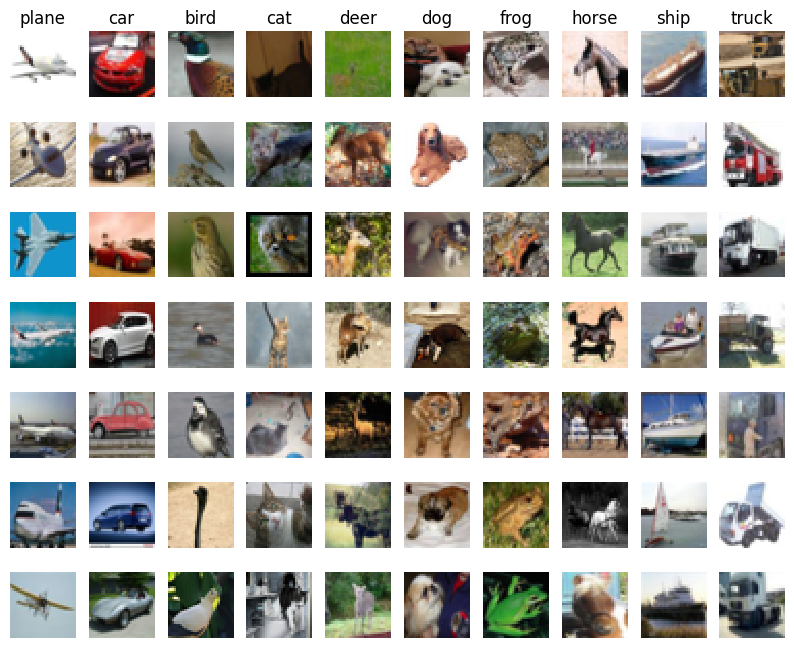

In [ ]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [ ]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [ ]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


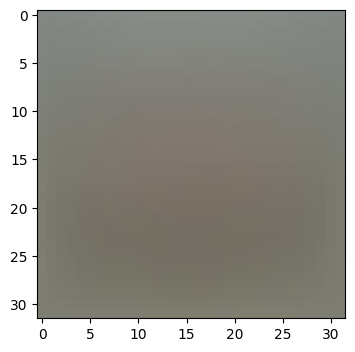

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [ ]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our classifier
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax Classifier

Your code for this section will all be written inside `cs231n/classifiers/softmax.py`.

As you can see, we have prefilled the function `softmax_loss_naive` which uses for loops to evaluate the softmax loss function.

In [ ]:
# Evaluate the naive implementation of the loss we provided for you:
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# generate a random Softmax classifier weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.366062
loss: 2.366062
sanity check: 2.302585


**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

$\color{blue}{\textit Your Answer:}$

在 Softmax 分类器初始化时，权重 W 通常被随机初始化为接近零的小数值。这意味着在计算 X.dot(W) 得到的分数 scores 也将是接近零的小数值。在 Softmax 函数中，这些分数被转换成代表每个类别的概率。由于所有分数都接近零且彼此相似，因此每个类别的概率将大致相等。对于一个有10个类别（CIFAR-10数据集）的分类问题，每个类别的初始概率大约是 1/10 = 0.1。

Softmax 损失函数的目标是最大化正确类别的对数概率。它的定义是 -log(P_correct_class)。因此，当模型未经训练，所有类别的概率都接近 0.1 时，损失值就会接近 -log(0.1)。

-log(0.1)≈-(-2.302585)≈2.302585


The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the softmax loss function and implement it inline inside the function `softmax_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

In [ ]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 1.314120 analytic: 1.314120, relative error: 6.461819e-08
numerical: -0.569696 analytic: -0.569696, relative error: 2.051050e-08
numerical: 0.377959 analytic: 0.377959, relative error: 4.184217e-08
numerical: 2.242926 analytic: 2.242926, relative error: 5.336142e-08
numerical: -1.090976 analytic: -1.090976, relative error: 1.854109e-08
numerical: -0.544008 analytic: -0.544008, relative error: 8.831227e-08
numerical: -0.642945 analytic: -0.642945, relative error: 1.214758e-08
numerical: 2.965350 analytic: 2.965350, relative error: 3.411460e-08
numerical: -1.630338 analytic: -1.630338, relative error: 8.937647e-09
numerical: -0.666450 analytic: -0.666450, relative error: 2.090013e-08
numerical: 2.988948 analytic: 2.988948, relative error: 2.241975e-08
numerical: 0.905745 analytic: 0.905745, relative error: 2.056889e-08
numerical: -0.181914 analytic: -0.181914, relative error: 2.459264e-07
numerical: 1.348924 analytic: 1.348924, relative error: 4.893410e-08
numerical: 0.887055 

**Inline Question 2**

Although gradcheck is reliable softmax loss, it is possible that for SVM loss, once in a while, a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a svm loss gradient check could fail? How would change the margin affect of the frequency of this happening?

$\color{blue}{\textit Your Answer:}$

1. **原因：** 这种差异是由 SVM 损失函数（Hinge Loss）的不可微点（Kinks）引起的。SVM 损失公式中包含 `max(0, x)`，该函数在 $x=0$ 处是不可导的。在进行数值梯度检查时，我们计算的是 $[f(x+h) - f(x-h)] / 2h$。如果 $x+h$ 和 $x-h$ 跨越了那个不可导的点（即 $s_j - s_{y_i} + \Delta = 0$ 的位置），那么数值梯度就会与在该点定义的解析梯度产生偏差。

2. **是否需要担心：** 通常**不需要担心**。这种不匹配是由于函数的数学特性导致的，而不是代码实现错误。只要这种现象发生的频率很低，且梯度在绝大多数点上是匹配的，模型训练就能正常进行。

3. **一维示例：** 考虑 $f(x) = \max(0, x)$，在 $x=0$ 处，解析梯度通常定义为 0（或左/右导数中的一个）。如果我们取步长 $h=0.1$，计算 $x=0.01$ 处的数值梯度：
   - $f(0.01 + 0.1) = 0.11$
   - $f(0.01 - 0.1) = 0$
   - 数值梯度 = $(0.11 - 0) / 0.2 = 0.55$
   - 而在该点解析梯度为 1。两者显然不匹配。

4. **Margin（$\Delta$）的影响：** 改变 Margin 的大小并不会从根本上改变失效的频率。失效的频率主要取决于得分之差 $s_j - s_{y_i}$ 落在 $-\Delta$ 附近的概率。但在实际操作中，如果 $\Delta$ 变大，可能会在初始化阶段让更多的样本进入 `max(0, ...)` 的“激活区域”，从而改变触碰不可微点的几率。总的来说，这种现象是结构性的，与具体的 $\Delta$ 值关系较小。

In [ ]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 2.366062e+00 computed in 0.059421s
Vectorized loss: 2.366062e+00 computed in 0.011000s
difference: -0.000000


In [ ]:
# Complete the implementation of softmax_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.082803s
Vectorized loss and gradient: computed in 0.016367s
difference: 0.000000


### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `cs231n/classifiers/linear_classifier.py`.

In [ ]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from cs231n.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 776.465515
iteration 100 / 1500: loss 285.286994
iteration 200 / 1500: loss 105.490491
iteration 300 / 1500: loss 39.938333
iteration 400 / 1500: loss 15.931564
iteration 500 / 1500: loss 7.158505
iteration 600 / 1500: loss 3.996171
iteration 700 / 1500: loss 2.762755
iteration 800 / 1500: loss 2.282538
iteration 900 / 1500: loss 2.196718
iteration 1000 / 1500: loss 2.152267
iteration 1100 / 1500: loss 2.138723
iteration 1200 / 1500: loss 2.094339
iteration 1300 / 1500: loss 2.079524
iteration 1400 / 1500: loss 2.130260
That took 8.983181s


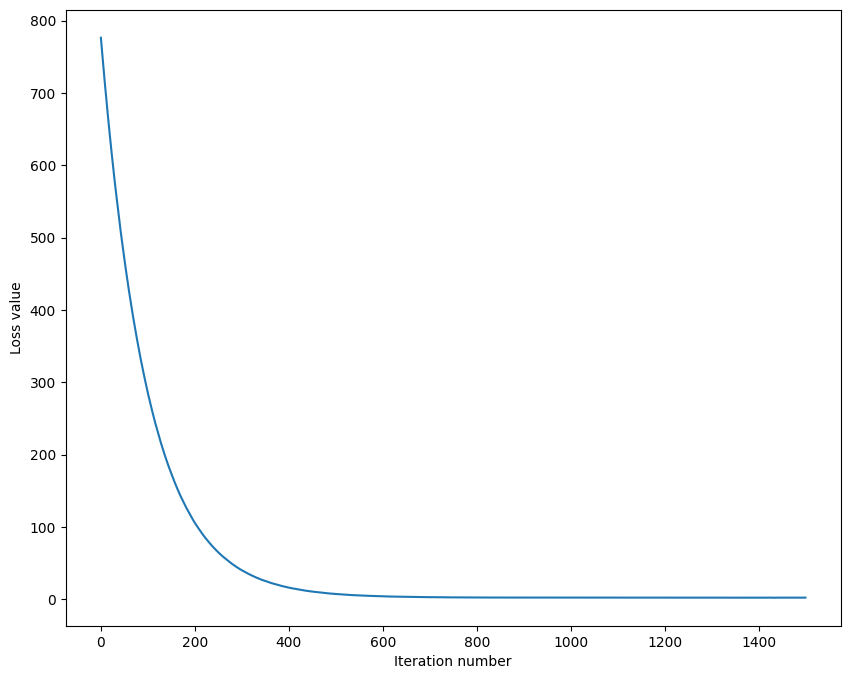

In [ ]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [ ]:
# Write the LinearClassifier.predict function and evaluate the performance on
# both the training and validation set
# You should get validation accuracy of about 0.34 (> 0.33).
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.332490
validation accuracy: 0.345000


In [ ]:
# Save the trained model for autograder.
softmax.save("softmax.npy")

softmax.npy saved.


In [ ]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.365 (> 0.36) on the validation set.

# Note: you may see runtime/overflow warnings during hyper-parameter search.
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_softmax = None # The Softmax object that achieved the highest validation rate.

################################################################################
# TODO:                                                                        #
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a Softmax on the.        #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the Softmax object that achieves this.   #
# accuracy in best_softmax.                                                    #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the classifiers don't take much time to train; once  #
# you are confident that your validation code works, you should rerun the      #
# code with a larger value for num_iters.                                      #
################################################################################

# Provided as a reference. You may or may not want to change these hyperparameters
# 使用 np.logspace 进行对数尺度搜索
learning_rates = np.logspace(-9, -2, 8)
regularization_strengths = np.logspace(-6, 6, 7)

# 将 numpy 数组转换为列表
learning_rates = learning_rates.tolist()
regularization_strengths = regularization_strengths.tolist()

# ====================== 【超参数搜索】 ======================
for lr in learning_rates:
    for reg in regularization_strengths:
        # 初始化 Softmax 分类器
        softmax = Softmax()

        # 训练
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=1500, verbose=False)

        # 计算训练集和验证集准确率
        y_train_pred = softmax.predict(X_train)
        y_val_pred = softmax.predict(X_val)

        train_acc = np.mean(y_train_pred == y_train)
        val_acc = np.mean(y_val_pred == y_val)

        # 保存结果
        results[(lr, reg)] = (train_acc, val_acc)

        # 更新最优模型
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax
# ============================================================================


# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

/content/drive/My Drive/cs231n/assignments/assignment1/cs231n/classifiers/softmax.py:95: RuntimeWarning: divide by zero encountered in log
  loss = -np.sum(np.log(p[np.arange(num_train), y]))
/content/drive/My Drive/cs231n/assignments/assignment1/cs231n/classifiers/softmax.py:98: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/content/drive/My Drive/cs231n/assignments/assignment1/cs231n/classifiers/softmax.py:98: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
/content/drive/My Drive/cs231n/assignments/assignment1/cs231n/classifiers/softmax.py:119: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W
/content/drive/My Drive/cs231n/assignments/assignment1/cs231n/classifiers/softmax.py:89: RuntimeWarning: invalid value encountere

lr 1.000000e-09 reg 1.000000e-06 train accuracy: 0.091469 val accuracy: 0.087000
lr 1.000000e-09 reg 1.000000e-04 train accuracy: 0.100184 val accuracy: 0.103000
lr 1.000000e-09 reg 1.000000e-02 train accuracy: 0.132531 val accuracy: 0.138000
lr 1.000000e-09 reg 1.000000e+00 train accuracy: 0.100673 val accuracy: 0.096000
lr 1.000000e-09 reg 1.000000e+02 train accuracy: 0.096959 val accuracy: 0.084000
lr 1.000000e-09 reg 1.000000e+04 train accuracy: 0.124224 val accuracy: 0.129000
lr 1.000000e-09 reg 1.000000e+06 train accuracy: 0.174061 val accuracy: 0.192000
lr 1.000000e-08 reg 1.000000e-06 train accuracy: 0.170122 val accuracy: 0.154000
lr 1.000000e-08 reg 1.000000e-04 train accuracy: 0.159041 val accuracy: 0.177000
lr 1.000000e-08 reg 1.000000e-02 train accuracy: 0.157959 val accuracy: 0.158000
lr 1.000000e-08 reg 1.000000e+00 train accuracy: 0.142082 val accuracy: 0.150000
lr 1.000000e-08 reg 1.000000e+02 train accuracy: 0.136102 val accuracy: 0.141000
lr 1.000000e-08 reg 1.000000

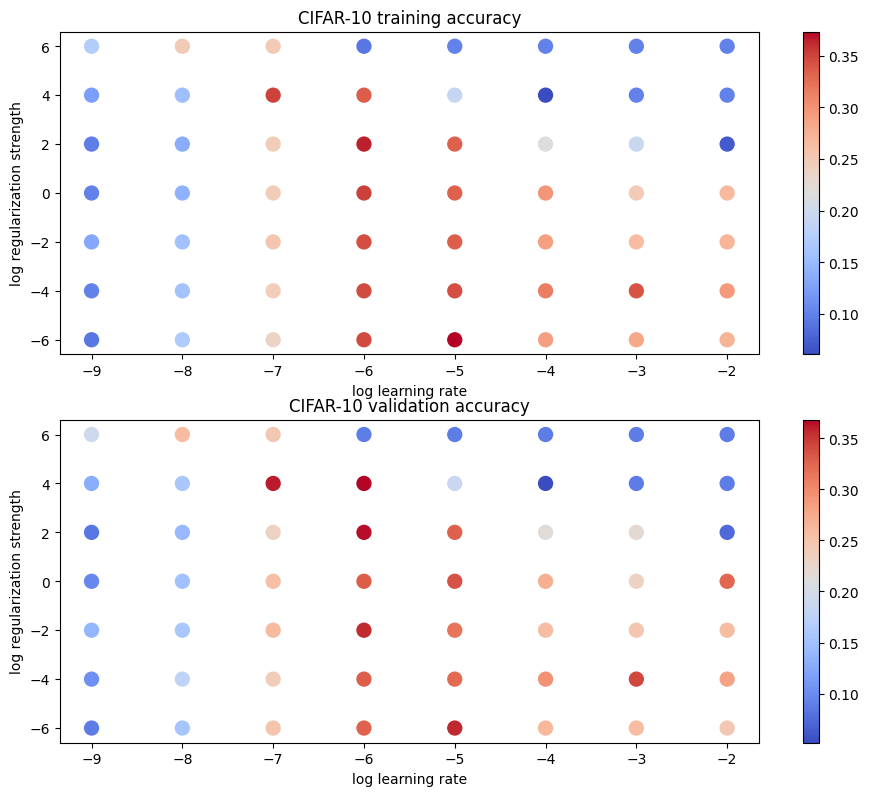

In [ ]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [ ]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

Softmax classifier on raw pixels final test set accuracy: 0.350000


In [ ]:
# Save best softmax model
best_softmax.save("best_softmax.npy")

best_softmax.npy saved.


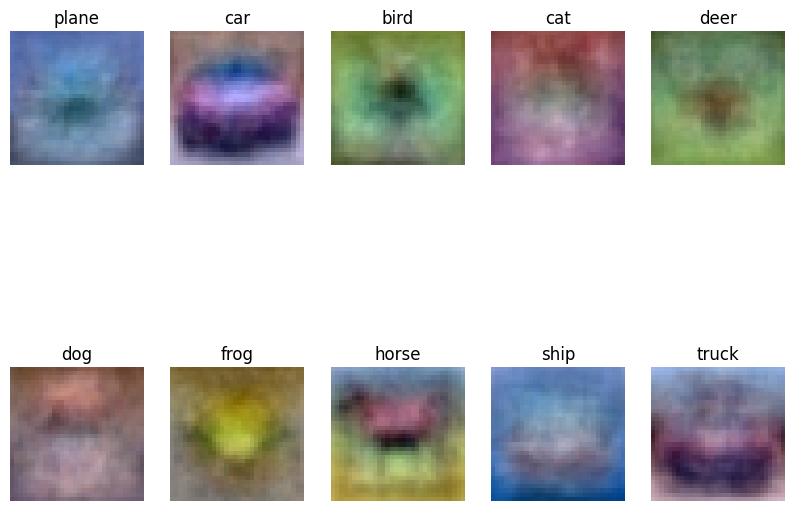

In [ ]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Inline question 3**

Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.

$\\color{blue}{\\textit Your Answer:}$

**Softmax 分类器权重的可视化结果看起来像什么，以及为什么它们会是这个样子？**

可视化后的 Softmax 分类器权重 (W) 对于每个类别，通常呈现出该类别的“平均模板”或者说“原型”图像。具体来说：

*   **形态特征**：每个类别对应的权重图像（32x32x3 像素）会显示出该类别中物体的一些典型颜色和形状特征。例如，代表“飞机”的权重图像可能会有一个大致的飞机形状，并且背景颜色可能与天空或跑道相似；“汽车”的权重图像可能包含车轮或车身的特征；“马”的权重图像可能会有马的头部或身体轮廓。
*   **颜色倾向**：权重图像的颜色会反映出该类别图像的平均颜色分布。例如，青蛙的权重图像可能偏绿，飞机可能偏蓝（天空）。
*   **模糊性**：这些“模板”通常比较模糊，不像清晰的物体图片。这是因为它们是对训练集中所有属于该类别的图像进行“平均”的结果。分类器试图找到一个能够最好地区分该类别与其他类别的通用模式。

**为什么它们会是这个样子？**

Softmax 分类器，作为一种线性分类器，它的工作原理是为每个类别学习一个权重向量（在可视化中就是这个“模板”）。当一张新图片输入时，分类器会计算这张图片与每个类别权重向量的点积（即相似度）。点积越大，表示图片与该类别的模板越相似，分类器就越倾向于将其分类到该类别。

因此，这些权重向量本质上就是分类器为每个类别学习到的一个“模板”或“特征检测器”。它试图捕捉该类别图像中所有像素的平均强度和颜色模式，使得当一张图片与这个“理想模板”越匹配时，得分就越高。当对这些权重进行可视化时，它们自然就呈现出类似该类别平均图像的形状和颜色了。

然而，由于这是一个线性模型，它的表达能力有限。它无法捕捉到物体在不同视角、不同姿态下的复杂变化，也无法识别出图像中的高级语义特征，这也是为什么像卷积神经网络（CNN）这样的非线性模型在图像识别任务中表现远超线性分类器的原因。

**Inline Question 4** - *True or False*

Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would change the softmax loss, but leave the SVM loss unchanged.

$\color{blue}{\textit Your Answer:}$ **True**

$\color{blue}{\textit Your Explanation:}$

**解释：**

这个说法是正确的。这主要是因为 Softmax 损失和 SVM 损失的定义以及它们对“正确分类”的理解不同。

1.  **SVM 损失 (Hinge Loss)**：
    *   SVM 损失的特点是存在一个“裕度”（margin），通常表示为 $\Delta$。对于一个数据点 $(x_i, y_i)$，如果正确类别的得分 $s_{y_i}$ 足够高，以至于 $s_{y_i} \ge s_j + \Delta$ 对于所有不正确类别 $j$ 都成立，那么这个数据点的 SVM 损失就为 0。即使 $s_{y_i}$ 变得更高，只要这个条件依然满足，其损失仍然是 0。
    *   因此，**如果新加入的数据点已经被模型正确分类，并且其分数满足了 SVM 的裕度条件，那么这个数据点的 SVM 损失就是 0，它不会增加总体的 SVM 损失。**

2.  **Softmax 损失 (Cross-Entropy Loss)**：
    *   Softmax 损失的定义是 $-\log(P_{y_i})$，其中 $P_{y_i}$ 是模型预测的正确类别的概率。Softmax 损失总是期望正确类别的概率尽可能接近 1。
    *   除非正确类别的预测概率**精确地达到 1**（这意味着所有不正确类别的概率都精确地为 0），否则 Softmax 损失**永远大于 0**。在实际的浮点数计算中，即使模型对一个数据点分类得非常好，其正确类别的概率也极少会正好是 1。
    *   因此，**新加入的任何数据点，无论模型对其分类有多好，只要其正确类别的概率不是完美的 1，它都会对总体的 Softmax 损失贡献一个正值，从而改变（增加）总体的 Softmax 损失。**

**总结：**

可以存在这样一个数据点：它被当前模型分类得非常好，以至于满足了 SVM 损失的裕度条件（损失为 0）。如果将这样的数据点添加到训练集中，它不会改变总的 SVM 损失。但同时，由于其正确类别的预测概率几乎不可能精确为 1，它一定会给总的 Softmax 损失贡献一个正值，从而增加了 Softmax 损失。所以，上述说法是正确的。